# P2 - RNNs

**Authors**:
- Pablo Diaz 
- Daniel Prieto

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

2026-05-02 13:32:10.112408: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-02 13:32:10.619231: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Load the data and preprocess it

In [2]:
df = pd.read_csv("data/nyiso_hourly_load.csv")
df.head()

,Time Stamp,CAPITL,CENTRL,DUNWOD,GENESE,HUD VL,LONGIL,MHK VL,MILLWD,N.Y.C.,NORTH,WEST,total_load
0,2021-01-01 05:00:00+00:00,1229.765829,1652.064229,601.434650,980.770850,1001.962714,2061.066821,841.068829,319.410071,4808.552936,635.814164,1525.174400,15657.085493
1,2021-01-01 06:00:00+00:00,1199.764783,1606.512858,579.089583,934.267075,960.858267,1946.459783,807.607275,307.969050,4631.978808,633.340358,1473.827217,15081.675058
2,2021-01-01 07:00:00+00:00,1172.361075,1578.671450,559.861700,913.383017,936.291717,1855.849567,796.252242,301.264983,4486.644667,617.937925,1435.501408,14654.019750
3,2021-01-01 08:00:00+00:00,1164.461967,1556.862842,548.799792,901.166967,916.932750,1797.270625,794.205750,295.269642,4372.209042,615.713533,1417.398217,14380.291125
4,2021-01-01 09:00:00+00:00,1177.303475,1561.628092,545.171408,898.999517,915.355317,1791.221000,798.552250,295.507442,4336.574433,615.466042,1419.729483,14355.508458


In [3]:
print(df.columns)

Index(['Time Stamp', 'CAPITL', 'CENTRL', 'DUNWOD', 'GENESE', 'HUD VL',
       'LONGIL', 'MHK VL', 'MILLWD', 'N.Y.C.', 'NORTH', 'WEST', 'total_load'],
      dtype='str')


Temporal Split 

- Training set: 2021–2023
- Validation set: 2024
- Test set: 2025

In [4]:
# split the data into training/validation/test sets

# Training Set 2021 to 2023
train_df = df[df["Time Stamp"] < "2024-01-01"]
print(len(train_df))

# Validation Set 2024
val_df = df[(df["Time Stamp"] >= "2024-01-01") & (df["Time Stamp"] < "2025-01-01")]
print(len(val_df))

# Test Set 2025
test_df = df[df["Time Stamp"] >= "2025-01-01"]
print(len(test_df))

# drop the "Time Stamp" column
train_df = train_df.drop(columns=["Time Stamp"])
val_df = val_df.drop(columns=["Time Stamp"])
test_df = test_df.drop(columns=["Time Stamp"])

26107
8784
8765


In [5]:
mean = train_df.mean()
std = train_df.std()

print(f"Mean:\n{mean}\n")
print(f"Standard Deviation:\n{std}\n")

Mean:
CAPITL         1327.515791
CENTRL         1736.799880
DUNWOD          646.373512
GENESE         1087.183369
HUD VL         1051.645915
LONGIL         2276.543855
MHK VL          837.988563
MILLWD          322.531092
N.Y.C.         5593.559854
NORTH           646.981059
WEST           1676.361131
total_load    17203.484021
dtype: float64

Standard Deviation:
CAPITL         233.315696
CENTRL         272.144257
DUNWOD         146.049529
GENESE         189.547436
HUD VL         232.391308
LONGIL         634.965917
MHK VL         159.596627
MILLWD          76.722991
N.Y.C.        1148.912783
NORTH           65.901310
WEST           224.922815
total_load    3085.204590
dtype: float64



In [6]:
train_df_scaled = (train_df - mean) / std
val_df_scaled = (val_df - mean) / std
test_df_scaled = (test_df - mean) / std

In [26]:
from keras.utils import timeseries_dataset_from_array

# sequences of 168 hours (1 week) to predict total load 3 hours ahead
sequence_length = 72
batch_size = 32
sample_rate = 1  # hourly data, so one sample per hour
delay = sample_rate * (sequence_length + 3 - 1)  # 3 hours in the future

train_ds = timeseries_dataset_from_array(
    data=train_df_scaled.values,
    targets=train_df_scaled["total_load"][delay:].values,
    sequence_length=sequence_length,
    batch_size=batch_size,
    shuffle=True,
)

val_ds = timeseries_dataset_from_array(
    data=val_df_scaled.values,
    targets=val_df_scaled["total_load"][delay:].values,
    sequence_length=sequence_length,
    batch_size=batch_size,
)

test_ds = timeseries_dataset_from_array(
    data=test_df_scaled.values,
    targets=test_df_scaled["total_load"][delay:].values,
    sequence_length=sequence_length,
    batch_size=batch_size,
)

In [22]:
epochs = 60

### Utils functions

### Plot

In [36]:
import matplotlib.pyplot as plt

def plot_mae(history, std=1.0):
    loss = [v * std for v in history.history["mae"]]
    val_loss = [v * std for v in history.history["val_mae"]]
    epochs = range(1, len(loss) + 1)
    plt.figure()
    plt.plot(epochs, loss, "b-o", label="Training MAE")
    plt.plot(epochs, val_loss, "r--o", label="Validation MAE")
    plt.title("Training and validation MAE")
    plt.ylabel("MAE (MW)")
    plt.xlabel("Epoch")
    plt.legend()
    plt.show()

## Baselines

### Last Value Baseline



In [37]:
mean_total = mean["total_load"]
std_total = std["total_load"]

def evaluate_baseline(dataset, get_pred_fn):
    total_abs_error = 0
    samples_counter = 0
    for samples, targets in dataset:
        preds = get_pred_fn(samples) * std_total + mean_total
        tgts = targets * std_total + mean_total
        total_abs_error += np.sum(np.abs(preds - tgts))
        samples_counter += samples.shape[0]
    return total_abs_error / samples_counter

# last observed total_load value (position -1 in window, feature -1 = total_load)
last_value_fn = lambda samples: samples[:, -1, -1]

print(f"Last Value — Validation MAE: {evaluate_baseline(val_ds, last_value_fn):.2f}")
print(f"Last Value — Test MAE:       {evaluate_baseline(test_ds, last_value_fn):.2f}")

2026-05-02 15:57:45.246096: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Last Value — Validation MAE: 1402.42
Last Value — Test MAE:       1400.09


### Last Day Baseline



In [38]:
# Target is 3h after the last element (pos 72), so 24h before target is pos 72+3-24 = 51
daily_fn = lambda samples: samples[:, 51, -1]

print(f"Daily Baseline — Validation MAE: {evaluate_baseline(val_ds, daily_fn):.2f}")
print(f"Daily Baseline — Test MAE:       {evaluate_baseline(test_ds, daily_fn):.2f}")

Daily Baseline — Validation MAE: 1018.31
Daily Baseline — Test MAE:       1116.56


## Part 2: Recurrent Models

For each model type we start with a base configuration (16 units, no regularization) and then explore:
- **Recurrent dropout** — applying a fixed dropout mask to recurrent activations (Gal & Ghahramani, 2016).
- **Stacked layers** — increasing model depth using `return_sequences=True` on the first layer.

All models use `rmsprop` optimizer and `batch_size=64` to keep comparisons fair.

### SimpleRNN

#### Base model

### Neural Baseline (Conv1D + Dense)

Epoch 1/30


2026-04-25 09:49:55.789738: I external/local_xla/xla/service/service.cc:163] XLA service 0x7e1b0001aa80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-25 09:49:55.789772: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Ti Laptop GPU, Compute Capability 8.6
2026-04-25 09:49:55.807976: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-25 09:49:55.884615: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92101
2026-04-25 09:49:55.899206: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-25 09:49:

 45/406 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7575 - mae: 0.6596

I0000 00:00:1777103398.464191    1478 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


406/406 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6318 - mae: 0.6236

2026-04-25 09:50:01.642925: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-25 09:50:01.871392: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_46', 8 bytes spill stores, 8 bytes spill loads

2026-04-25 09:50:02.073133: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_46', 20 bytes spill stores, 20 bytes spill loads

2026-04-25 09:50:02.224093: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_46', 556 bytes spi

406/406 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.6040 - mae: 0.6147 - val_loss: 0.5710 - val_mae: 0.5984
Epoch 2/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5800 - mae: 0.6038 - val_loss: 0.5906 - val_mae: 0.6100
Epoch 3/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5651 - mae: 0.5971 - val_loss: 0.6341 - val_mae: 0.6221
Epoch 4/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5511 - mae: 0.5898 - val_loss: 0.5820 - val_mae: 0.6005
Epoch 5/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5353 - mae: 0.5802 - val_loss: 0.5554 - val_mae: 0.5901
Epoch 6/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5233 - mae: 0.5729 - val_loss: 0.5921 - val_mae: 0.5940
Epoch 7/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5107 - mae: 0.5652 - val_loss: 0.7321 - val_mae: 0.6867
Epoch 8/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4986 - mae: 0.5572 - val_loss: 0.5903 - val_mae: 0.6102
Epoch 9/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4893

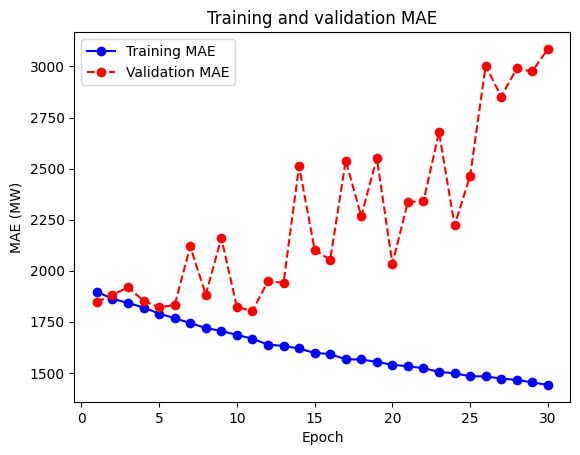

In [12]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.Conv1D(64, 5, activation="relu")(inputs)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(1)(x)
model_conv = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)
]
model_conv.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_conv = model_conv.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

model_conv = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model_conv.evaluate(test_ds)[1] * std_total:.2f}")

plot_mae(history_conv, std=std_total)

In [13]:
import keras
from keras import layers

inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.SimpleRNN(64)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_rnn.keras", save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_simple_rnn = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

model = keras.models.load_model("jena_rnn.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")

Epoch 1/30


2026-04-25 09:51:04.069860: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-25 09:51:04.069908: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-25 09:51:04.069915: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-25 09:51:04.997919: I external/l

404/406 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1843 - mae: 0.2863

2026-04-25 09:51:20.220150: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_30', 16 bytes spill stores, 16 bytes spill loads



406/406 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.1838 - mae: 0.2859

2026-04-25 09:51:21.963760: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-25 09:51:22.173394: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_13', 8 bytes spill stores, 8 bytes spill loads

2026-04-25 09:51:22.349170: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_13', 20 bytes spill stores, 20 bytes spill loads

2026-04-25 09:51:22.483472: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_13', 504 bytes spi

406/406 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 0.0824 - mae: 0.2000 - val_loss: 0.1007 - val_mae: 0.2472
Epoch 2/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - loss: 0.0292 - mae: 0.1321 - val_loss: 0.0376 - val_mae: 0.1446
Epoch 3/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - loss: 0.0253 - mae: 0.1221 - val_loss: 0.0368 - val_mae: 0.1472
Epoch 4/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - loss: 0.0232 - mae: 0.1172 - val_loss: 0.0298 - val_mae: 0.1308
Epoch 5/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - loss: 0.0217 - mae: 0.1131 - val_loss: 0.0336 - val_mae: 0.1384
Epoch 6/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - loss: 0.0205 - mae: 0.1099 - val_loss: 0.0447 - val_mae: 0.1620
Epoch 7/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - loss: 0.0201 - mae: 0.1083 - val_loss: 0.0322 - val_mae: 0.1353
Epoch 8/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - loss: 0.0192 - mae: 0.1062 - val_loss: 0.0298 - val_mae: 0.1314
Epoch 9/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/st

2026-04-25 09:58:16.295721: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_13', 16 bytes spill stores, 16 bytes spill loads



135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0440 - mae: 0.1512
Test MAE: 466.60


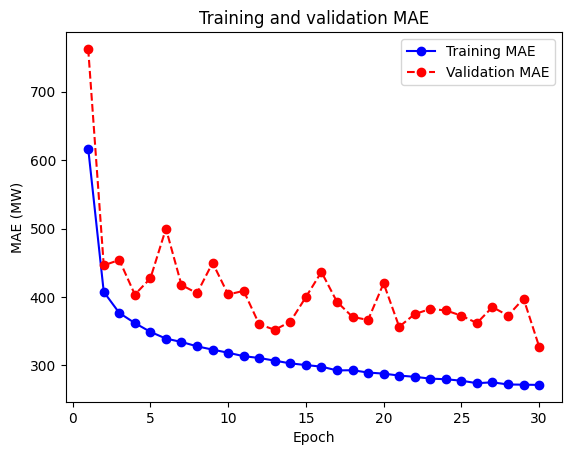

In [14]:
plot_mae(history_simple_rnn, std=std_total)

#### SimpleRNN with recurrent dropout

The base model overfits quickly. We add `recurrent_dropout=0.25` on the recurrent connections and a `Dropout(0.5)` layer after the RNN, and increase units to 32. We train for 20 epochs to observe the regularization effect.

We do not explore stacking for SimpleRNN: its known vanishing-gradient problem makes deeper stacks unreliable, and LSTM/GRU are better suited for that.

Epoch 1/30


2026-04-25 09:58:17.414592: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-25 09:58:17.870438: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_28', 200 bytes spill stores, 200 bytes spill loads

2026-04-25 09:58:18.263936: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_28', 11580 bytes spill stores, 11276 bytes spill loads



406/406 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 0.4214 - mae: 0.4993 - val_loss: 0.1312 - val_mae: 0.2853
Epoch 2/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - loss: 0.1855 - mae: 0.3406 - val_loss: 0.0946 - val_mae: 0.2409
Epoch 3/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - loss: 0.1568 - mae: 0.3109 - val_loss: 0.0955 - val_mae: 0.2451
Epoch 4/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - loss: 0.1404 - mae: 0.2941 - val_loss: 0.0828 - val_mae: 0.2236
Epoch 5/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - loss: 0.1328 - mae: 0.2842 - val_loss: 0.0855 - val_mae: 0.2256
Epoch 6/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - loss: 0.1276 - mae: 0.2781 - val_loss: 0.0896 - val_mae: 0.2369
Epoch 7/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - loss: 0.1219 - mae: 0.2713 - val_loss: 0.0794 - val_mae: 0.2216
Epoch 8/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - loss: 0.1202 - mae: 0.2698 - val_loss: 0.0845 - val_mae: 0.2327
Epoch 9/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/st

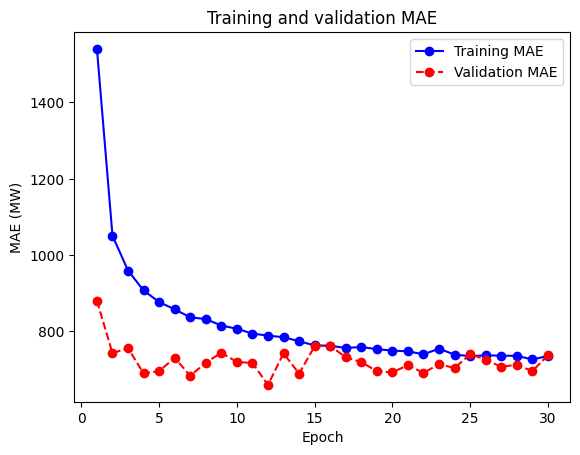

In [15]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.SimpleRNN(64, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_rnn_dropout.keras", save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_rnn_dropout = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

model = keras.models.load_model("jena_rnn_dropout.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")

plot_mae(history_rnn_dropout, std=std_total)

### LSTM

#### Base model

In [33]:
import keras
from keras import layers
from keras import regularizers

inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.LSTM(128, kernel_regularizer=regularizers.l2(1e-4))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True),
    keras.callbacks.EarlyStopping(
            monitor="val_loss", 
            patience=15, 
            restore_best_weights=True, 
            verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
            patience=5, min_lr=0.00001)
]

custom_optimizer = keras.optimizers.RMSprop(learning_rate=0.001, clipvalue=1.0)

model.compile(optimizer=custom_optimizer, loss="mse", metrics=["mae"])
history_lstm = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

model = keras.models.load_model("jena_lstm.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")

Epoch 1/60
814/814 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.0663 - mae: 0.1845 - val_loss: 0.0345 - val_mae: 0.1364 - learning_rate: 0.0010
Epoch 2/60
814/814 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0292 - mae: 0.1247 - val_loss: 0.0303 - val_mae: 0.1273 - learning_rate: 0.0010
Epoch 3/60
814/814 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0231 - mae: 0.1096 - val_loss: 0.0498 - val_mae: 0.1727 - learning_rate: 0.0010
Epoch 4/60
814/814 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0200 - mae: 0.1015 - val_loss: 0.0279 - val_mae: 0.1197 - learning_rate: 0.0010
Epoch 5/60
814/814 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0182 - mae: 0.0961 - val_loss: 0.0230 - val_mae: 0.1092 - learning_rate: 0.0010
Epoch 6/60
814/814 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0170 - mae: 0.0929 - val_loss: 0.0263 - val_mae: 0.1221 - learning_rate: 0.0010
Epoch 7/60
814/814 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0160 - mae: 0.0899 - val_loss: 0.0258 - val_mae: 0.1158 - learning_rate: 0.

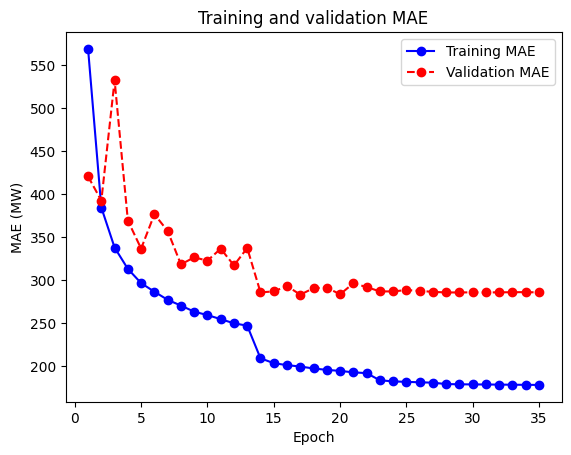

In [34]:
plot_mae(history_lstm, std=std_total)

#### LSTM with recurrent dropout

We apply the same regularization strategy as with SimpleRNN: `recurrent_dropout=0.25` on the LSTM and `Dropout(0.5)` on its output, with 32 units and 20 training epochs.

Epoch 1/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 235s 575ms/step - loss: 0.2180 - mae: 0.3629 - val_loss: 0.0838 - val_mae: 0.2277
Epoch 2/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 226s 556ms/step - loss: 0.1151 - mae: 0.2662 - val_loss: 0.0588 - val_mae: 0.1885
Epoch 3/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 224s 551ms/step - loss: 0.0932 - mae: 0.2377 - val_loss: 0.0491 - val_mae: 0.1704
Epoch 4/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 226s 556ms/step - loss: 0.0840 - mae: 0.2248 - val_loss: 0.0440 - val_mae: 0.1600
Epoch 5/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 224s 553ms/step - loss: 0.0816 - mae: 0.2189 - val_loss: 0.0400 - val_mae: 0.1526
Epoch 6/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 224s 552ms/step - loss: 0.0767 - mae: 0.2129 - val_loss: 0.0378 - val_mae: 0.1483
Epoch 7/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 224s 552ms/step - loss: 0.0823 - mae: 0.2167 - val_loss: 0.0388 - val_mae: 0.1506
Epoch 8/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 222s 546ms/step - loss: 0.0724 - mae: 0.2060 - val_loss: 0.0377 - val_mae: 0.1477
Epoch 9/30
406/406 ━━━━━

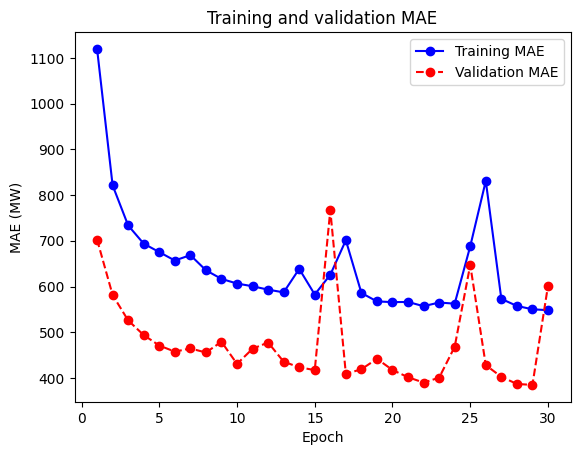

In [18]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.LSTM(64, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm_dropout.keras", save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_lstm_dropout = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

model = keras.models.load_model("jena_lstm_dropout.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")

plot_mae(history_lstm_dropout, std=std_total)

#### Stacked LSTM

To increase model capacity we stack two LSTM layers. The first must use `return_sequences=True` to pass the full output sequence to the second. We use stronger dropout (`recurrent_dropout=0.5`) to compensate for the additional capacity, and train for 30 epochs.

Epoch 1/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 480s 1s/step - loss: 0.2693 - mae: 0.4033 - val_loss: 0.1203 - val_mae: 0.2698
Epoch 2/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 477s 1s/step - loss: 0.1334 - mae: 0.2846 - val_loss: 0.0833 - val_mae: 0.2260
Epoch 3/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 482s 1s/step - loss: 0.1034 - mae: 0.2485 - val_loss: 0.0665 - val_mae: 0.2019
Epoch 4/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 481s 1s/step - loss: 0.0928 - mae: 0.2335 - val_loss: 0.0796 - val_mae: 0.2170
Epoch 5/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 477s 1s/step - loss: 0.0828 - mae: 0.2212 - val_loss: 0.0592 - val_mae: 0.1895
Epoch 6/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 477s 1s/step - loss: 0.0783 - mae: 0.2145 - val_loss: 0.0502 - val_mae: 0.1708
Epoch 7/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 476s 1s/step - loss: 0.0723 - mae: 0.2054 - val_loss: 0.0482 - val_mae: 0.1656
Epoch 8/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 479s 1s/step - loss: 0.0680 - mae: 0.1990 - val_loss: 0.0664 - val_mae: 0.1917
Epoch 9/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 475s 1s/

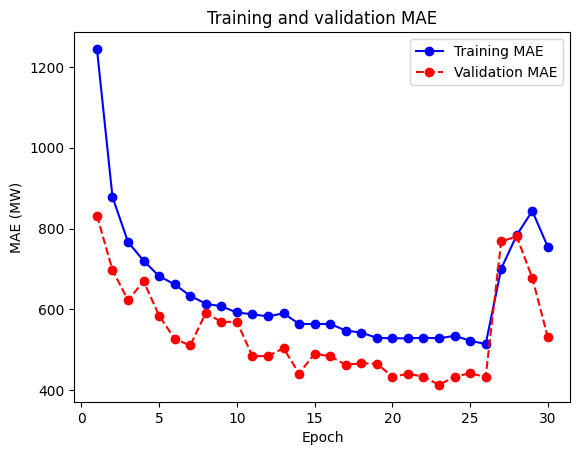

In [19]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.LSTM(64, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.LSTM(64, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm_stacked.keras", save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_lstm_stacked = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

model = keras.models.load_model("jena_lstm_stacked.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")

plot_mae(history_lstm_stacked, std=std_total)

### GRU

#### Base model

Learning rate mas agresivo para evitar eebote en los minimos globales

Prueba: La capa GRU se encarga de extraer características temporales complejas. Al pasar esas características por una capa Dense intermedia (generalmente con activación ReLU), para una etapa extra de procesamiento no lineal para interpretar esos patrones antes de colapsarlos en un solo número con un dropout para evitatr overfitting -> Se intentó darle más profundidad al modelo y empeoró el rendimiento, demuestra un nivel de análisis, lo que implica que el modelo GRU de 128 ya tenía la capacidad perfecta para este problema y no necesitaba más capas.

Batch size reducido de 64 a 32 para optimizar la búsqueda de un mínimo óptimo y reducir la probabilidad de que el modelo se estanque en mínimos locales

Añadida regularización l2 para reducir overfitting 

In [29]:
import keras
from keras import layers
from keras import regularizers

inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.GRU(128, kernel_regularizer=regularizers.l2(1e-4))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_gru.keras", save_best_only=True),
    keras.callbacks.EarlyStopping(
            monitor="val_loss", 
            patience=15, 
            restore_best_weights=True, 
            verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
            patience=5, min_lr=0.00001)
]

custom_optimizer = keras.optimizers.RMSprop(learning_rate=0.001, clipvalue=1.0)

model.compile(optimizer=custom_optimizer, loss="mse", metrics=["mae"])
history_gru = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

model = keras.models.load_model("jena_gru.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")

Epoch 1/60
814/814 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0687 - mae: 0.1897 - val_loss: 0.0412 - val_mae: 0.1493 - learning_rate: 0.0010
Epoch 2/60
814/814 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0289 - mae: 0.1251 - val_loss: 0.0397 - val_mae: 0.1482 - learning_rate: 0.0010
Epoch 3/60
814/814 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0241 - mae: 0.1135 - val_loss: 0.0313 - val_mae: 0.1298 - learning_rate: 0.0010
Epoch 4/60
814/814 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0216 - mae: 0.1072 - val_loss: 0.0300 - val_mae: 0.1267 - learning_rate: 0.0010
Epoch 5/60
814/814 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0200 - mae: 0.1030 - val_loss: 0.0288 - val_mae: 0.1251 - learning_rate: 0.0010
Epoch 6/60
814/814 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0189 - mae: 0.1001 - val_loss: 0.0245 - val_mae: 0.1135 - learning_rate: 0.0010
Epoch 7/60
814/814 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0182 - mae: 0.0974 - val_loss: 0.0221 - val_mae: 0.1073 - learning_rate: 0.001

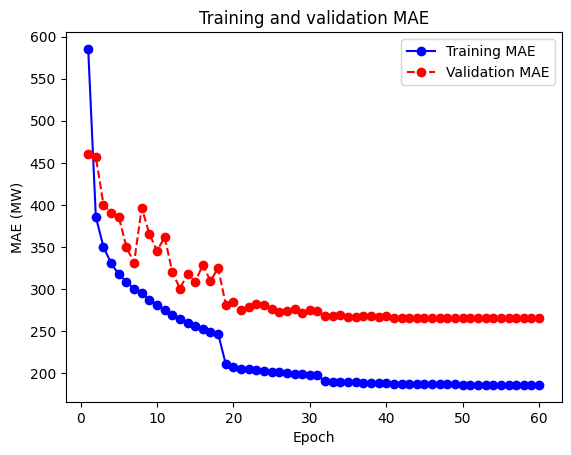

In [30]:
plot_mae(history_gru, std=std_total)

#### GRU with recurrent dropout

Same regularization as LSTM: `recurrent_dropout=0.25`, `Dropout(0.5)`, 32 units, 20 epochs. GRU has fewer parameters than LSTM so it trains faster.

Epoch 1/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 317s 776ms/step - loss: 0.2063 - mae: 0.3499 - val_loss: 0.0713 - val_mae: 0.2095
Epoch 2/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 311s 765ms/step - loss: 0.1127 - mae: 0.2612 - val_loss: 0.0562 - val_mae: 0.1857
Epoch 3/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 309s 761ms/step - loss: 0.0976 - mae: 0.2419 - val_loss: 0.0473 - val_mae: 0.1711
Epoch 4/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 312s 767ms/step - loss: 0.0880 - mae: 0.2306 - val_loss: 0.0481 - val_mae: 0.1708
Epoch 5/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 304s 748ms/step - loss: 0.0827 - mae: 0.2218 - val_loss: 0.0503 - val_mae: 0.1776
Epoch 6/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 317s 780ms/step - loss: 0.0784 - mae: 0.2150 - val_loss: 0.0374 - val_mae: 0.1514
Epoch 7/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 303s 746ms/step - loss: 0.0741 - mae: 0.2098 - val_loss: 0.0370 - val_mae: 0.1490
Epoch 8/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 307s 757ms/step - loss: 0.0725 - mae: 0.2070 - val_loss: 0.0483 - val_mae: 0.1707
Epoch 9/30
406/406 ━━━━━

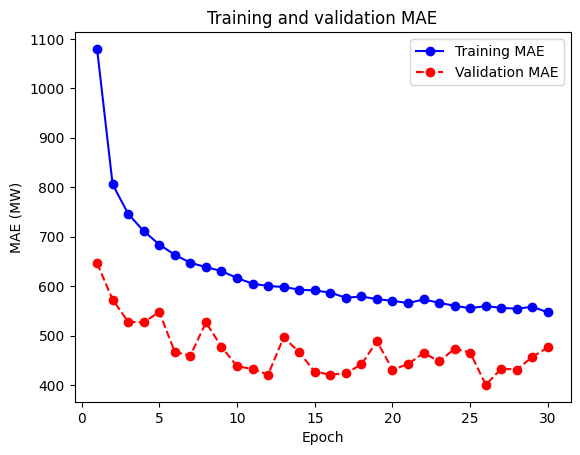

In [22]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.GRU(64, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_gru_dropout.keras", save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_gru_dropout = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

model = keras.models.load_model("jena_gru_dropout.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")

plot_mae(history_gru_dropout, std=std_total)

#### Stacked GRU

Two stacked GRU layers with strong dropout regularization (`recurrent_dropout=0.5`) and 30 training epochs, following the same pattern as stacked LSTM.

Epoch 1/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 494s 1s/step - loss: 0.2165 - mae: 0.3591 - val_loss: 0.0852 - val_mae: 0.2308
Epoch 2/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 462s 1s/step - loss: 0.1204 - mae: 0.2708 - val_loss: 0.0552 - val_mae: 0.1806
Epoch 3/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 474s 1s/step - loss: 0.0987 - mae: 0.2441 - val_loss: 0.0474 - val_mae: 0.1695
Epoch 4/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 493s 1s/step - loss: 0.0901 - mae: 0.2324 - val_loss: 0.0525 - val_mae: 0.1797
Epoch 5/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 473s 1s/step - loss: 0.0826 - mae: 0.2228 - val_loss: 0.0470 - val_mae: 0.1737
Epoch 6/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 480s 1s/step - loss: 0.0775 - mae: 0.2151 - val_loss: 0.0447 - val_mae: 0.1646
Epoch 7/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 504s 1s/step - loss: 0.0721 - mae: 0.2063 - val_loss: 0.0521 - val_mae: 0.1772
Epoch 8/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 525s 1s/step - loss: 0.0688 - mae: 0.2020 - val_loss: 0.0430 - val_mae: 0.1608
Epoch 9/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 519s 1s/

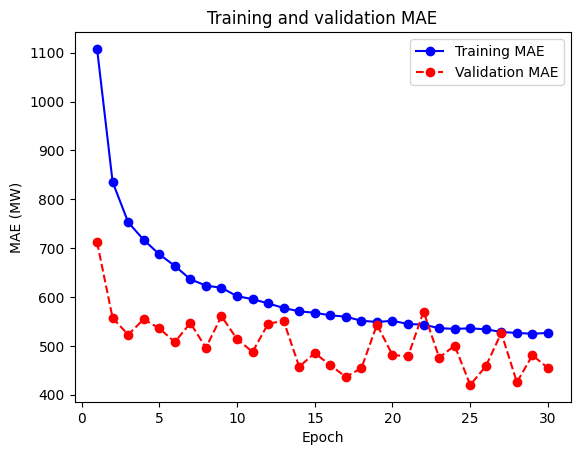

In [23]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.GRU(64, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(64, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_gru_stacked.keras", save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_gru_stacked = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

model = keras.models.load_model("jena_gru_stacked.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")

plot_mae(history_gru_stacked, std=std_total)

## Analysis and Comparison

We collect all test MAEs (denormalized, in MW) and display them in a single table and bar chart.

2026-05-02 15:58:43.212112: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-02 15:58:43.940286: I external/local_xla/xla/service/service.cc:163] XLA service 0x43def340 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-02 15:58:43.940334: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Ti Laptop GPU, Compute Capability 8.6
2026-05-02 15:58:43.994646: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777730325.056113   28418 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-05-02 15:58:48.316846: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to loca

                         Model  Test MAE (MW)
           Last Value Baseline        1400.09
                Daily Baseline        1116.56
        Conv1D Neural Baseline        1868.24
          SimpleRNN (64 units)         468.20
SimpleRNN + Dropout (64 units)         693.49
              LSTM (128 units)         366.41
     LSTM + Dropout (64 units)         544.08
           LSTM Stacked (64×2)         543.42
               GRU (128 units)         335.16
      GRU + Dropout (64 units)         476.81
            GRU Stacked (64×2)         505.95


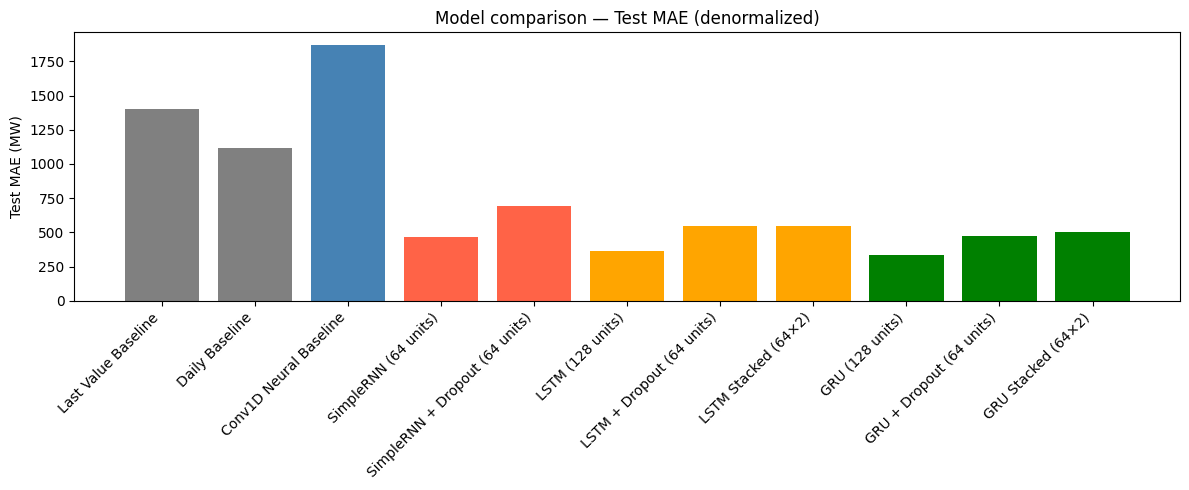

In [39]:
import pandas as pd

def get_test_mae(model_path):
    m = keras.models.load_model(model_path)
    return m.evaluate(test_ds, verbose=0)[1] * std_total

model_names = [
    "Last Value Baseline",
    "Daily Baseline",
    "Conv1D Neural Baseline",
    "SimpleRNN (64 units)",
    "SimpleRNN + Dropout (64 units)",
    "LSTM (128 units)",
    "LSTM + Dropout (64 units)",
    "LSTM Stacked (64×2)",
    "GRU (128 units)",
    "GRU + Dropout (64 units)",
    "GRU Stacked (64×2)",
]

test_maes = [
    evaluate_baseline(test_ds, last_value_fn),
    evaluate_baseline(test_ds, daily_fn),
    get_test_mae("jena_conv.keras"),
    get_test_mae("jena_rnn.keras"),
    get_test_mae("jena_rnn_dropout.keras"),
    get_test_mae("jena_lstm.keras"),
    get_test_mae("jena_lstm_dropout.keras"),
    get_test_mae("jena_lstm_stacked.keras"),
    get_test_mae("jena_gru.keras"),
    get_test_mae("jena_gru_dropout.keras"),
    get_test_mae("jena_gru_stacked.keras"),
]

results_df = pd.DataFrame({"Model": model_names, "Test MAE (MW)": test_maes})
results_df["Test MAE (MW)"] = results_df["Test MAE (MW)"].round(2)
print(results_df.to_string(index=False))

# Bar chart
plt.figure(figsize=(12, 5))
colors = ["gray", "gray", "steelblue",
          "tomato", "tomato",
          "orange", "orange", "orange",
          "green", "green", "green"]
plt.bar(model_names, test_maes, color=colors)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test MAE (MW)")
plt.title("Model comparison — Test MAE (denormalized)")
plt.tight_layout()
plt.show()